# Harmony Filtering Service Demo

This notebook shows how to run the core filtering pipeline, using the  
`settings.json` and `config.json` in `config/`.

Before running, make sure:

```bash
pip install -r docs/requirements.txt

In [1]:
# 1️⃣ Set up imports
import json
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

from harmony_filtering_service.adapter_utils import load_and_prepare_settings
from harmony_filtering_service.core import process_products

# so that inline plots appear
%matplotlib inline

In [2]:
# 2️⃣ Load and prepare the settings.json
settings_path = Path("../config/settings.json")
settings = load_and_prepare_settings(settings_path)
print("Data dir:", settings["data_dir"])
print("Output dir:", settings["output_dir"])

Data dir: /Users/srizvi/Documents/PI25.2/harmony-filtering/docs/data/in_data
Output dir: /Users/srizvi/Documents/PI25.2/harmony-filtering/docs/data/out_data


In [3]:
# 3️⃣ Load the filter config (config/config.json)
cfg_path = Path("../config/config.json")
config = json.loads(cfg_path.read_text(encoding="utf-8"))
config

{'O3TOT': {'filters': {'pixel_filter': [{'target_var': 'product/column_amount_o3',
     'criteria_var': 'geolocation/solar_zenith_angle',
     'operator': 'greater-than',
     'threshold': '80',
     'target_value': 'nan',
     'level': 'all'},
    {'target_var': 'product/column_amount_o3',
     'criteria_var': 'product/quality_flag',
     'operator': 'greater-than-or-equal-to',
     'threshold': '4096',
     'target_value': 'nan',
     'level': '2'},
    {'target_var': 'product/fc',
     'criteria_var': 'geolocation/solar_zenith_angle',
     'operator': 'greater-than',
     'threshold': '80',
     'target_value': 'nan',
     'level': 'all'},
    {'target_var': 'product/uv_aerosol_index',
     'criteria_var': 'geolocation/solar_zenith_angle',
     'operator': 'greater-than',
     'threshold': '80',
     'target_value': 'nan',
     'level': 'all'},
    {'target_var': 'product/uv_aerosol_index',
     'criteria_var': 'geolocation/viewing_zenith_angle',
     'operator': 'greater-than',
   

In [4]:
# 4️⃣ Run the filtering pipeline
process_products(settings, config)
print("✅ Done filtering.")

No file found for product 'O3TOT'. Skipping.
No file found for product 'CLDO4'. Skipping.
No file found for product 'HCHO'. Skipping.
Processing product 'NO2'
File: /Users/srizvi/Documents/PI25.2/harmony-filtering/docs/data/in_data/TEMPO_NO2_L3_V03_20241124T213121Z_S012.nc
Metadata extracted from filename:
  Instrument: TEMPO
  Product: NO2
  Level: 3
  Version: V03
  Timestamp: 20241124T213121Z
  Sequence: S012
Before applying filters:
  Primary variable 'vertical_column_troposphere': min = -8.21530654545078e+16, max = 1.4820526938351293e+17, total NaNs = 18082081
  Primary variable 'vertical_column_stratosphere': min = 802912148570665.5, max = 2542732068248669.0, total NaNs = 18082081
Filter rule '1': secondary variable 'product/main_data_quality_flag' non-nan count = 114549
Filter rule '2': secondary variable 'geolocation/solar_zenith_angle' non-nan count = 1090486
Filter rule '3': secondary variable 'product/main_data_quality_flag' non-nan count = 114549
Filter rule '4': secondary 

Original: /Users/srizvi/Documents/PI25.2/harmony-filtering/docs/data/in_data/TEMPO_NO2_L3_V03_20241124T213121Z_S012.nc
Filtered: /Users/srizvi/Documents/PI25.2/harmony-filtering/docs/data/out_data/TEMPO_NO2_L3_V03_20241124T213121Z_S012_filtered.nc


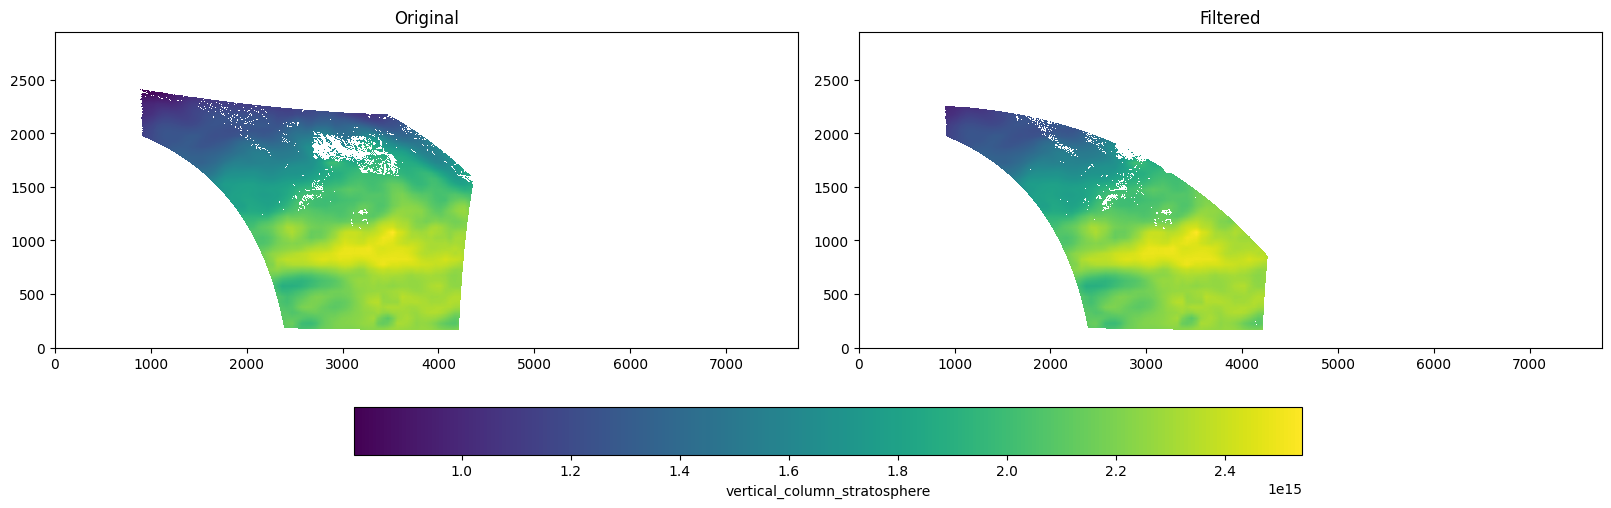

In [5]:
from pathlib import Path

# 1️⃣ find files
in_dir = Path(settings["data_dir"])
out_dir = Path(settings["output_dir"])
filtered = next(out_dir.glob("*_filtered.nc"))
original = in_dir / filtered.name.replace("_filtered.nc", ".nc")

print("Original:", original)
print("Filtered:", filtered)

# 2️⃣ open them
ds_orig = xr.open_dataset(original, group="product")
ds_filt = xr.open_dataset(filtered, group="product")

da_orig = ds_orig["vertical_column_stratosphere"]
da_filt = ds_filt["vertical_column_stratosphere"]


# 3️⃣ helper to get a pure 2D slice
def to_2d(da):
    # if there's a time dimension, grab the first timestep
    if "time" in da.dims:
        da2 = da.isel(time=0)
    else:
        da2 = da.squeeze()
    if da2.ndim != 2:
        raise ValueError(f"Cannot make 2D from dims {da2.dims}")
    return da2


da_o2 = to_2d(da_orig)
da_f2 = to_2d(da_filt)

# 4️⃣ plot side by side with common color scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# first get color limits from the original
vmin, vmax = float(da_o2.min()), float(da_o2.max())

im1 = da_o2.plot.pcolormesh(ax=ax1, add_colorbar=False, vmin=vmin, vmax=vmax)
ax1.set_title("Original")
ax1.set_xlabel("")
ax1.set_ylabel("")

im2 = da_f2.plot.pcolormesh(ax=ax2, add_colorbar=False, vmin=vmin, vmax=vmax)
ax2.set_title("Filtered")
ax2.set_xlabel("")
ax2.set_ylabel("")

# 5️⃣ shared colorbar
cbar = fig.colorbar(im2, ax=(ax1, ax2), orientation="horizontal", pad=0.1)
cbar.set_label("vertical_column_stratosphere")

plt.show()